In [1]:
import requests
import pandas as pd
# Biblioteka time przyda się do delikatnego opóźnienia zapytań, aby nie obciążać API
import time 

url = "https://api.openalex.org/works"

params = {
    "filter": "primary_location.source.issn:0239-6858|2449-8998",
    "per-page": 200, # Ustawiamy maksimum dla szybszego pobierania
    "mailto": "twoj_adres@email.pl",
    "cursor": "*" # Etap 1: Wskazanie początku paginacji
}

extracted_data = []

# Etap 2: Pętla pobierająca wszystkie strony
while True:
    response = requests.get(url, params=params)
    
    # Zabezpieczenie na wypadek błędu serwera
    if response.status_code != 200:
        print(f"Błąd połączenia. Kod statusu: {response.status_code}")
        break
        
    data = response.json()
    
    # Przetwarzanie i ekstrakcja z bieżącej paczki wyników
    for work in data.get("results", []):
        title = work.get("title")
        pub_year = work.get("publication_year")
        cited_by = work.get("cited_by_count")
        
        concepts_raw = work.get("concepts", [])
        concepts_names = ", ".join([c.get("display_name") for c in concepts_raw])
        
        extracted_data.append({
            'tytuł': title,
            'rok': pub_year,
            'cytowania': cited_by,
            'słowa kluczowe': concepts_names
        })
        
    # Etap 3: Pobranie adresu następnej strony z sekcji "meta"
    meta = data.get("meta", {})
    next_cursor = meta.get("next_cursor")
    
    # Warunek zakończenia pętli – brak kolejnych wyników
    if not next_cursor:
        print("Pobieranie zakończone.")
        break
        
    # Aktualizacja kursora przed kolejnym obiegiem pętli
    params["cursor"] = next_cursor
    
    # Krótkie opóźnienie (0.1 sekundy) dobrą praktyką przy web scrapingu/API
    time.sleep(0.1)

# Stworzenie ramki danych Pandas ze wszystkich pobranych wyników
dane = pd.DataFrame(extracted_data)

# Wyświetlenie rozmiaru pobranej ramki oraz pierwszych 5 wierszy
print(f"Pobrano łącznie {len(dane)} rekordów.")
display(dane.head())

Pobieranie zakończone.
Pobrano łącznie 335 rekordów.


,tytuł,rok,cytowania,słowa kluczowe
0,Research Ethics: A Perspective of South Asian ...,2021,9,"Research ethics, Context (archaeology), Perspe..."
1,Edukacja dzieci z doświadczeniami migracyjnymi...,2018,6,"Sociology, Compulsory education, Political sci..."
2,Edukacja i komunikacja międzykulturowa w kszta...,2018,5,"Multiculturalism, Intercultural communication,..."
3,The prestige of the teaching profession in the...,2017,21,"Prestige, Perception, Psychology, Pedagogy, Ma..."
4,Reading engagement and school achievement of l...,2017,13,"Reading (process), Mathematics education, Psyc..."


--- Statystyki cytowań dla kwartalnika Edukacja ---
Średnia liczba cytowań: 0.72
Mediana cytowań: 0.00
Odchylenie standardowe: 2.09
Udział artykułów bez cytowań: 72.84%



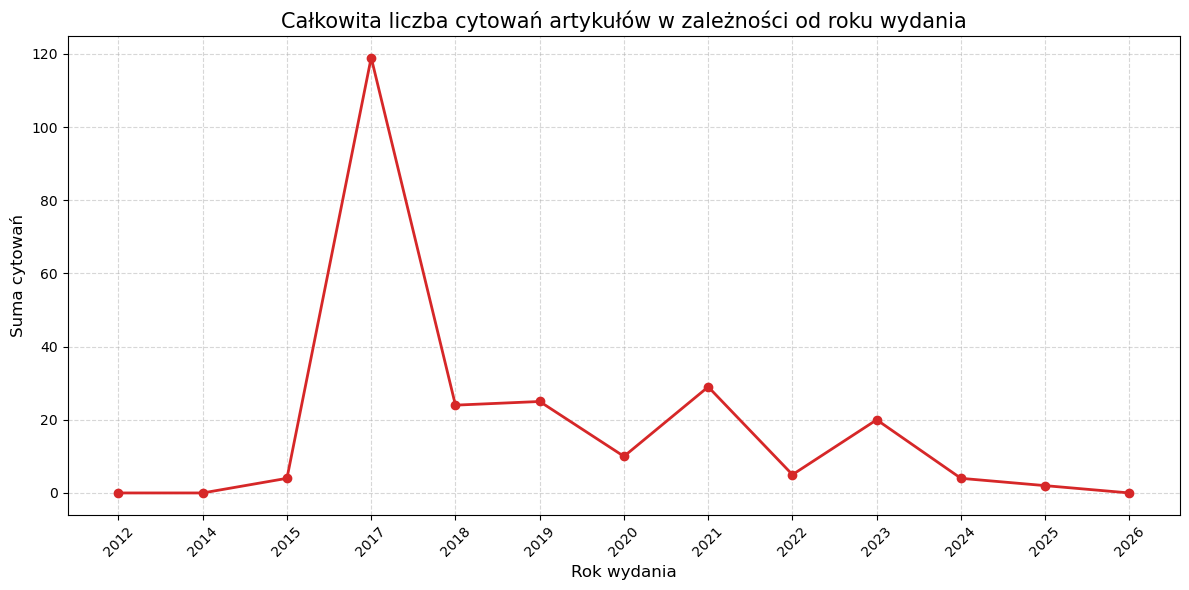

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Upewniamy się, że pracujemy na prawidłowych typach danych, usuwając braki w kluczowych kolumnach
df = dane.dropna(subset=['cytowania', 'rok']).copy()
df['cytowania'] = pd.to_numeric(df['cytowania'], errors='coerce').fillna(0)

# Etap 1: Wyliczenie statystyk
srednia = df['cytowania'].mean()
mediana = df['cytowania'].median()
odchylenie = df['cytowania'].std()

liczba_wszystkich = len(df)
liczba_zerowych = (df['cytowania'] == 0).sum()
udzial_zerowych = (liczba_zerowych / liczba_wszystkich) * 100

# Wyświetlenie wyników w konsoli
print("--- Statystyki cytowań dla kwartalnika Edukacja ---")
print(f"Średnia liczba cytowań: {srednia:.2f}")
print(f"Mediana cytowań: {mediana:.2f}")
print(f"Odchylenie standardowe: {odchylenie:.2f}")
print(f"Udział artykułów bez cytowań: {udzial_zerowych:.2f}%\n")

# Etap 2: Grupowanie danych po roku i sumowanie cytowań
cytowania_w_czasie = df.groupby('rok')['cytowania'].sum().sort_index()

# Konwersja indeksu (lat) na liczby całkowite dla spójnego formatowania osi
cytowania_w_czasie.index = cytowania_w_czasie.index.astype(int)

# Etap 3: Tworzenie wykresu liniowego
plt.figure(figsize=(12, 6))

plt.plot(
    cytowania_w_czasie.index.astype(str), # Konwersja na tekst zapobiega przerwom w osi X
    cytowania_w_czasie.values, 
    marker='o', 
    color='#d62728', 
    linewidth=2,
    markersize=6
)

# Konfiguracja estetyki
plt.title("Całkowita liczba cytowań artykułów w zależności od roku wydania", fontsize=15)
plt.xlabel("Rok wydania", fontsize=12)
plt.ylabel("Suma cytowań", fontsize=12)

# Poprawa czytelności osi i tła
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Wyświetlenie wykresu
plt.show()

In [3]:
import pandas as pd

# Etap 1: Rozdzielenie ciągów znaków po przecinku i rozbicie na pojedyncze wiersze
rozwiniete_slowa = dane['słowa kluczowe'].dropna().str.split(', ').explode()

# Etap 2: Wyciągnięcie wyłącznie unikalnych słów
unikalne_slowa_lista = rozwiniete_slowa.unique()

# Etap 3: Stworzenie nowej ramki danych z jedną kolumną
df_unikalne = pd.DataFrame(unikalne_slowa_lista, columns=['Unikalne słowa kluczowe'])

# Posortowanie wyników alfabetycznie i zresetowanie indeksu dla porządku
df_unikalne = df_unikalne.sort_values(by='Unikalne słowa kluczowe').reset_index(drop=True)

# Wyświetlenie liczby znalezionych unikalnych słów oraz pierwszych 10 wyników
print(f"Liczba unikalnych słów kluczowych: {len(df_unikalne)}")
display(df_unikalne.head(10))

Liczba unikalnych słów kluczowych: 456


,Unikalne słowa kluczowe
0,2019-20 coronavirus outbreak
1,Academic community
2,Academic integrity
3,Accounting
4,Acculturation
5,Action (physics)
6,Actuarial science
7,Adaptation (eye)
8,Adaptive capacity
9,Adult education


In [4]:
import pandas as pd

# Pracujemy na kopii głównej ramki danych, aby nie uszkodzić oryginału
df = dane.copy()

# Usuwamy wiersze, w których brakuje roku publikacji lub słów kluczowych
df = df.dropna(subset=['słowa kluczowe', 'rok'])

# Etap 1: Rozdzielenie ciągów znaków i rozbicie (explode) ramki danych
df['słowa kluczowe'] = df['słowa kluczowe'].str.split(', ')
df_exploded = df.explode('słowa kluczowe')

# Odrzucenie ewentualnych pustych ciągów znaków (jeśli takie powstały)
df_exploded = df_exploded[df_exploded['słowa kluczowe'].str.strip() != ""]

# Etap 2: Tworzenie macierzy za pomocą tabeli krzyżowej
macierz = pd.crosstab(
    index=df_exploded['słowa kluczowe'], 
    columns=df_exploded['rok']
)

# Etap 3: Sortowanie macierzy alfabetycznie po indeksie (słowach kluczowych)
macierz = macierz.sort_index()

# Wyświetlenie informacji o wymiarach tabeli oraz pierwszych 10 wierszy
print(f"Utworzono macierz: {macierz.shape[0]} słów kluczowych (wiersze) na {macierz.shape[1]} lat (kolumny).")
display(macierz.head())

Utworzono macierz: 456 słów kluczowych (wiersze) na 13 lat (kolumny).


rok,2012,2014,2015,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
słowa kluczowe,,,,,,,,,,,,,
2019-20 coronavirus outbreak,0,0,0,0,0,0,0,0,0,0,1,0,0
Academic community,0,0,0,0,0,0,0,1,0,0,0,0,0
Academic integrity,0,0,0,0,0,0,0,2,0,0,0,0,0
Accounting,0,0,0,1,0,0,0,0,0,0,0,0,0
Acculturation,0,0,0,0,1,0,0,0,0,0,0,0,0


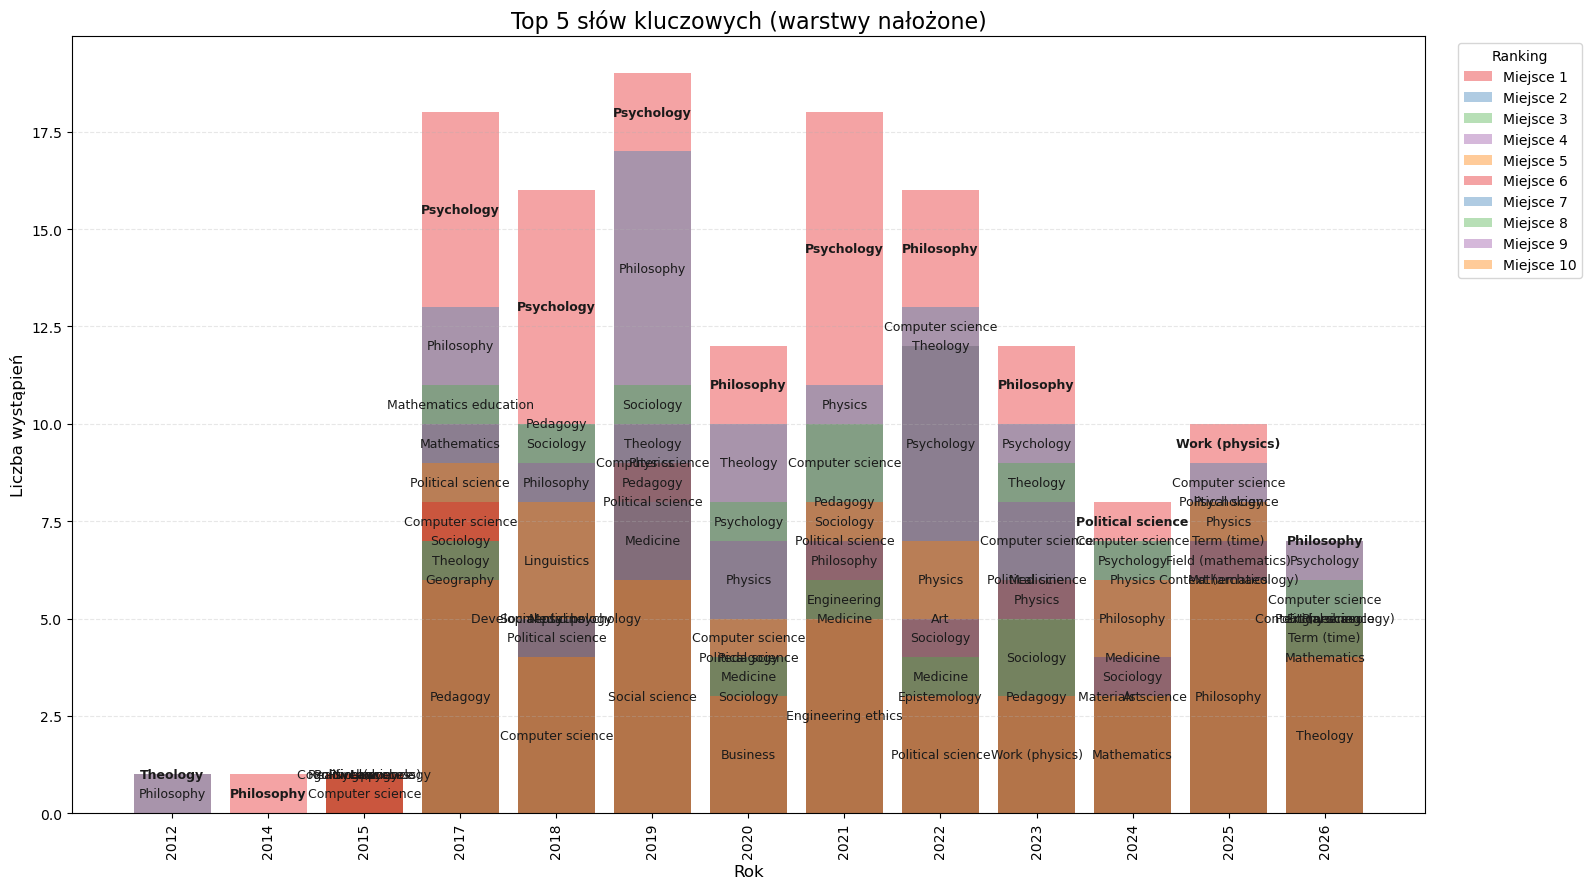

In [5]:
import matplotlib.pyplot as plt

# Zbieranie danych pozostaje bez zmian
lata_str = [str(int(rok)) for rok in macierz.columns]

rank_wartosci = {i: [] for i in range(10)}
rank_slowa = {i: [] for i in range(10)}

for rok in macierz.columns:
    top5 = macierz[rok].sort_values(ascending=False).head(10)
    
    for i in range(10):
        if i < len(top5):
            rank_wartosci[i].append(top5.iloc[i])
            rank_slowa[i].append(top5.index[i])
        else:
            rank_wartosci[i].append(0) 
            rank_slowa[i].append("")

# Konstrukcja wykresu
plt.figure(figsize=(16, 9))
kolory = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00','#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00','#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00',]

for i in range(10):
    slupki = plt.bar(
        lata_str, 
        rank_wartosci[i], 
        color=kolory[i], 
        alpha=0.4, 
        label=f'Miejsce {i+1}'
    )
    
    for idx, (slupek, slowo) in enumerate(zip(slupki, rank_slowa[i])):
        wysokosc = slupek.get_height()
        
        if wysokosc > 0:
            wysokosc_nastepnego = rank_wartosci[i+1][idx] if i < 9 else 0
            pozycja_y = (wysokosc + wysokosc_nastepnego) / 2
            
            plt.text(
                slupek.get_x() + slupek.get_width() / 2, 
                pozycja_y, 
                slowo, 
                ha='center', 
                va='center', 
                rotation=0, # ZMIANA: Ustawienie kąta na 0 stopni (tekst poziomy)
                fontsize=9,
                color='#1a1a1a',
                fontweight='bold' if i == 0 else 'normal'
            )

# Konfiguracja estetyki
plt.title("Top 5 słów kluczowych (warstwy nałożone)", fontsize=16)
plt.xlabel("Rok", fontsize=12)
plt.ylabel("Liczba wystąpień", fontsize=12)

# Obrót etykiet osi X (lata zostawiamy obrócone, aby na siebie nie nachodziły)
plt.xticks(rotation=90)

plt.legend(title="Ranking", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

# Wyświetlenie wykresu
plt.show()